In [1]:
# 변수의 shape, type, value 확인
def p(var,_str='') :
    if _str=='\n' or _str=='cr' :
        _str = '\n'
    else :
        print(f'[{_str}]:')
        _str = ''
    if type(var)!=type([]):
        try:
            print(f'Shape:{var.shape}')
        except :
            pass
    print(f'Type: {type(var)}')
    print(f'Values: {var}'+_str)

def pst(_x,_name=""):
    print(f'[{_name}] Shape{_x.shape}, {type(_x)}')
def ps(_x,_name=""):
    print(f'[{_name}] Shape{_x.shape}')

In [2]:
!pip -q install lightning torchinfo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 828.5/828.5 kB 27.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 58.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 832.4/832.4 kB 62.4 MB/s eta 0:00:00


# CNN model handling

# 실습 : Modern CNN

## Import Module

In [3]:
import torch
from torch import nn
from torch.nn import functional as F
from torchmetrics import functional as FM
from torch.utils.data import DataLoader, random_split
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision.transforms import v2
from torchinfo import summary

import lightning as L
from lightning.pytorch import Trainer
from lightning.pytorch.callbacks import ModelCheckpoint
from lightning.pytorch.loggers import CSVLogger

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [5, 3.5]
plt.rcParams["font.size"] = "8"

device ='cuda:0'
torch.__version__,L.__version__

('2.8.0+cu126', '2.5.5')

## DataSet

- *Load*

In [4]:
from torchvision.datasets import FashionMNIST, MNIST, CIFAR10
from torch.utils.data import DataLoader, Subset

transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True) ] )

batch_size=512

## Fashion MNIST
download_root = './F-MNIST'
train_dataset = FashionMNIST(download_root, transform=transform, train=True, download=True)
test_dataset = FashionMNIST(download_root, transform=transform, train=False, download=True)

D_name = "Fashion MNIST"
# ## MNIST
# download_root = './MNIST'
# train_dataset = MNIST(download_root, transform=transform, train=True, download=True)
# test_dataset = MNIST(download_root, transform=transform, train=False, download=True)
# D_name = "MNIST"

# download_root = './CIFAR10'
# train_dataset = CIFAR10(download_root, transform=transform, train=True, download=True)
# test_dataset = CIFAR10(download_root, transform=transform, train=False, download=True)
# D_name = "CIFAR10"

trainDataLoader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
valDataLoader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4)


100%|██████████| 26.4M/26.4M [00:02<00:00, 11.9MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 203kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.77MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 18.1MB/s]


## Model

In [5]:
class Wrap_10(L.LightningModule):
    def training_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self(x)
        loss = F.cross_entropy(y_pred, y)
        acc = FM.accuracy(y_pred, y, task="multiclass",num_classes=10)
        metrics={'loss':loss, 'acc':acc}
        self.log_dict(metrics,prog_bar=True,on_step=False,on_epoch=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self(x)
        loss = F.cross_entropy(y_pred, y)
        acc = FM.accuracy(y_pred, y, task="multiclass",num_classes=10)
        metrics={'val_loss':loss, 'val_acc':acc}
        self.log_dict(metrics,prog_bar=True,on_step=False,on_epoch=True)

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=0.001)

In [ ]:
epochs=30

### 5layer CNN model


In [ ]:
class CNN(Wrap_10):
    def __init__(self):
        super(CNN, self).__init__()
        self.layers = nn.Sequential(
            nn.Conv2d(1, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(128, 256, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Flatten(),
            nn.Linear(256*3*3, 1000),
            nn.Linear(1000, 10))

    def forward(self, x):
        out = self.layers(x)
        return out

cnn = CNN()
summary(cnn, input_size=(8, 1, 28, 28))

- training

In [ ]:
%%time
cnn = CNN()

#epochs=30
logger = CSVLogger("logs", name="cnn_basic")
trainer = Trainer(max_epochs=epochs, logger=logger,enable_model_summary=False,
                     limit_train_batches=0.20,limit_val_batches=0.2) # Wall time: 49 s
trainer.fit(cnn, trainDataLoader, val_dataloaders=valDataLoader)

cnn_v_num = logger.version
#Wall time: 38.5 s

### Dropout 적용 모델

In [ ]:
class CNN_DO(Wrap_10):
    def __init__(self):
        super(CNN_DO, self).__init__()
        self.layers = nn.Sequential(
            nn.Conv2d(1, 64, 3, padding=1),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(128, 256, 3, padding=1),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.MaxPool2d(2, 2),

            nn.Flatten(),
            nn.Linear(256*3*3, 1000),
            nn.Linear(1000, 10))

    def forward(self, x):
        out = self.layers(x)
        return out

model_DO = CNN_DO()
summary(model_DO, input_size=(8, 1, 28, 28))

In [ ]:
%%time
model_DO = CNN_DO()

logger = CSVLogger("logs", name="cnn_drop_out")
trainer = Trainer(max_epochs=epochs, logger=logger,enable_model_summary=False,
                     limit_train_batches=0.20,limit_val_batches=0.2)
trainer.fit(model_DO, trainDataLoader, val_dataloaders=valDataLoader)

model_DO_v_num = logger.version

Wall time: 48.2 s

### Batch Normalization 적용 모델

In [ ]:
class CNN_BN(Wrap_10):
    def __init__(self):
        super(CNN_BN, self).__init__()
        self.layers = nn.Sequential(
            nn.Conv2d(1, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.MaxPool2d(2, 2),

            nn.Flatten(),
            nn.Linear(256*3*3, 1000),
            nn.Linear(1000, 10))

    def forward(self, x):
        out = self.layers(x)
        return out

model_BN = CNN_BN()
summary(model_BN, input_size=(8, 1, 28, 28))

In [ ]:
%%time
model_BN = CNN_BN()

logger = CSVLogger("logs", name="cnn_batchnorm")
trainer = Trainer(max_epochs=epochs, logger=logger,enable_model_summary=False,
                     limit_train_batches=0.20,limit_val_batches=0.2)
trainer.fit(model_BN, trainDataLoader, val_dataloaders=valDataLoader)

model_BN_v_num = logger.version

### *Plot*

In [ ]:
history1 = pd.read_csv(f'./logs/cnn_basic/version_{cnn_v_num}/metrics.csv')
history2 = pd.read_csv(f'./logs/cnn_drop_out/version_{model_DO_v_num}/metrics.csv')
history3 = pd.read_csv(f'./logs/cnn_batchnorm/version_{model_BN_v_num}/metrics.csv')

h1 = history1.drop('step', axis=1).groupby('epoch').last()
h2 = history2.drop('step', axis=1).groupby('epoch').last()
h3 = history3.drop('step', axis=1).groupby('epoch').last()

In [ ]:
max_1 = h1['val_acc'].max()
max_2 = h2['val_acc'].max()
max_3 = h3['val_acc'].max()

plt.figure(figsize=(12,3))
title = D_name
plt.subplot(121)
plt.title(f"{title}\nMax Val_Acc(CNN / DO / BN)\n{max_1:.4f} / {max_2:.4f} / {max_3:.4f}")
plt.plot(h1['val_acc'], label='val_acc1')
plt.plot(h2['val_acc'], label='val_acc2')
plt.plot(h3['val_acc'], label='val_acc3')
# plt.plot(h1['acc'],'--', label='acc1')
# plt.plot(h2['acc'],'--', label='acc2')
# plt.plot(h3['acc'],'--', label='acc3')
plt.ylim(0.6, )
plt.legend()
plt.grid()

plt.subplot(122)
plt.title("Loss")
plt.plot(h1['val_loss'], label='val_loss1')
plt.plot(h2['val_loss'], label='val_loss2')
plt.plot(h3['val_loss'], label='val_loss3')
# plt.plot(h1['loss'],'--', label='loss1')
# plt.plot(h2['loss'],'--', label='loss2')
# plt.plot(h3['loss'],'--', label='loss3')
plt.semilogy()
plt.legend()
plt.grid()
plt.show()

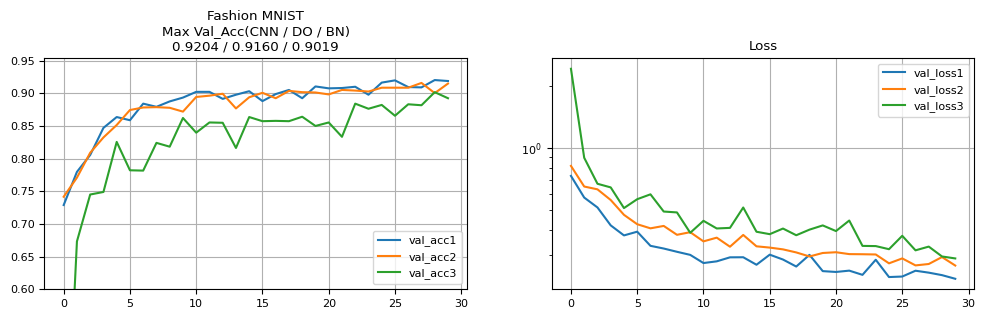

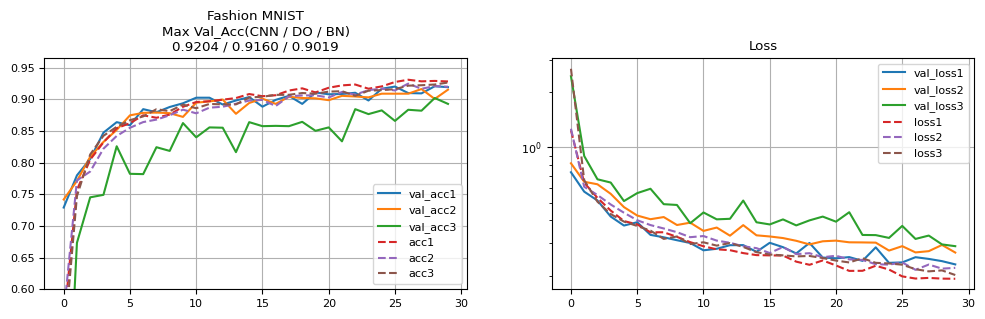

# **실습과제**

#### 과제1
**Dataset을 CIFAR-10으로 수정하고**  
**최고 성능이 82%이상이 되도록 모델을 개선하자**  
 (batch_size=512, epoch=30 사용)  
-- 결과 plot을 보고 성능 향상을 위해 무엇을 해볼지 검토해 보자  
-- Conv. block을 추가해 보자  
-- Dense(1000) layer를 Dense(256)을 바꿔 보자  
-- Conv. block에 dropout layer를 추가해 보자  
-- Dense(10) layer 앞에 dropout layer를 추가해 보자  
-- Conv. block에 conv. layer를 추가해 보자  
-- Dense(256)layer를 제거해 보자    
> #### limit_train_batches=0.5 적용


#### 과제2
**learning rate schedule을 적용해 보자**  
**최고성능이 85%이상이 되도록 scheduler를 튜닝해 보자**  
-- start_learning_rate, decay_steps, decay_rate를 수정해 보자  
-- 모델의 학습속에 따라 적당한 학습률을 어떻게 결정할 것인가?  

- **Learning Rate Scheduling 참고 코드**

In [ ]:
epochs=30
lr_start = 0.001

In [ ]:
decay_steps = epochs//3.5
decay_rate=0.5
def exponential_decay_lambda(epoch):
    return decay_rate ** (epoch // decay_steps)

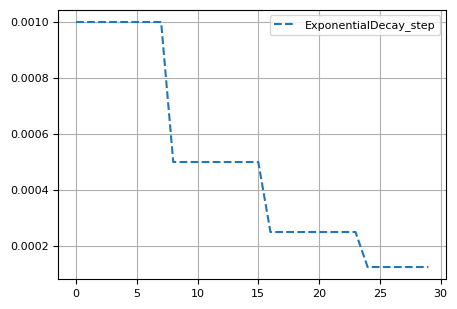

In [ ]:
exp_lr_s=[]

for step in range(epochs):
    exp_lr_s.append(exponential_decay_lambda(step)*lr_start)

plt.plot(exp_lr_s, linestyle='--', label="ExponentialDecay_step")
plt.legend()
plt.grid()

In [ ]:
class CNN_1(CNN): ## Inherit the CNN model
    def __init__(self):
        super(CNN_1, self).__init__()

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=lr_start)

- define lr scheduling

In [ ]:
class CNN_2(CNN): ## Inherit the CNN model
    def __init__(self):
        super(CNN_2, self).__init__()

    def configure_optimizers(self):
        optimizer =  torch.optim.Adam(self.parameters(), lr=lr_start)
        lr_scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda = exponential_decay_lambda)
        return [optimizer], [lr_scheduler]

# 과제 1

In [ ]:
from torchvision.datasets import FashionMNIST, MNIST, CIFAR10
from torch.utils.data import DataLoader, Subset

transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True) ] )

batch_size=512
download_root = './CIFAR10'

train_dataset = CIFAR10(download_root, transform=transform, train=True, download=True)
test_dataset = CIFAR10(download_root, transform=transform, train=False, download=True)

trainDataLoader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=7)
valDataLoader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=7)

## Model define

In [ ]:
class CNN_BN(Wrap_10):
    def __init__(self):
        super(CNN_BN, self).__init__()
        self.layers = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # nn.Conv2d(64, 64, 3, padding=1),
            # nn.BatchNorm2d(64),
            # nn.ReLU(),
            # nn.Dropout(0.2),
            # nn.MaxPool2d(2, 2),

            nn.Flatten(),
#            nn.Linear(256*3*3, 1000),
#            nn.Dropout(0.2),
#            nn.Linear(1000, 10)
            )
    def forward(self, x):
        out = self.layers(x)
        return out

model_BN = CNN_BN()
summary(model_BN, input_size=(8, 3, 32, 32))

## Training

In [ ]:
%%time
### limit_train_batches=0.5 적용 ###
epochs=30

logger = CSVLogger("logs", name="cnn_batchnorm")
trainer = Trainer(max_epochs=epochs, logger=logger,enable_model_summary=False,
                     limit_train_batches=0.5,limit_val_batches=0.2)
trainer.fit(model_BN, trainDataLoader, val_dataloaders=valDataLoader)

model_BN_v_num = logger.version

limit_train_batches=0.5,limit_val_batches=0.2  
> Wall time: 3min 31s

### *Plot*

In [ ]:
history = pd.read_csv(f'./logs/cnn_batchnorm/version_{model_BN_v_num}/metrics.csv')
h1 = history.drop('step', axis=1).groupby('epoch').last()

In [ ]:
max_1 = h1['val_acc'].max()

plt.figure(figsize=(10,3))
title = "CNN_improved"
plt.subplot(121)
plt.title(f"{title}\nMax Val_Acc:{max_1:.4f}")
plt.plot(h1['acc'],'--', label='acc')
plt.plot(h1['val_acc'], label='val_acc')
#plt.ylim(0.3, )
plt.legend()
plt.grid()

plt.subplot(122)
plt.title("Loss")
plt.plot(h1['loss'],'--', label='loss')
plt.plot(h1['val_loss'], label='val_loss')
#plt.semilogy()
plt.legend()
plt.grid()
plt.show()

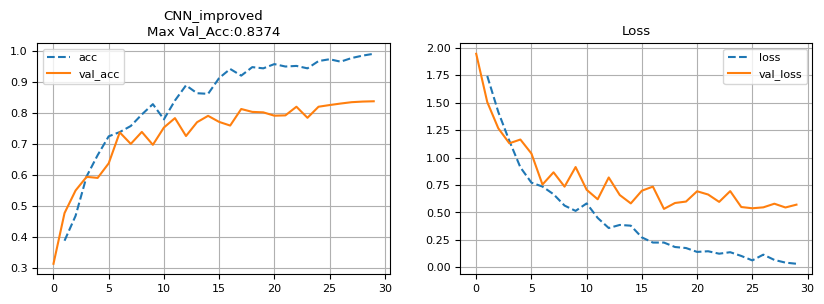

# 과제 2 : learning rate schedule

In [ ]:
epochs=30
lr_start = 0.001

## Scheduler design

In [ ]:
decay_steps = epochs//3
decay_rate=0.5
def exponential_decay_lambda(epoch):
    return decay_rate ** (epoch // decay_steps)

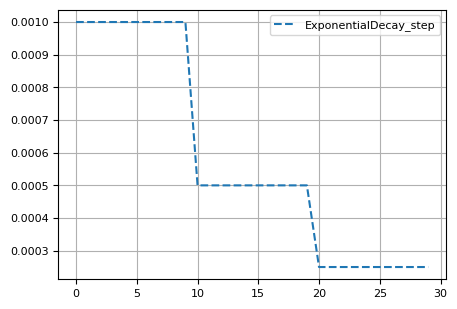

In [ ]:
exp_lr_s=[]

for step in range(epochs):
    exp_lr_s.append(exponential_decay_lambda(step)*lr_start)

plt.plot(exp_lr_s, linestyle='--', label="ExponentialDecay_step")
plt.legend()
plt.grid()

## Model define

In [ ]:
class CNN_2(CNN_BN): ## Inherit the CNN model
    def __init__(self):
        super(CNN_2, self).__init__()

    def configure_optimizers(self):
        optimizer =  torch.optim.Adam(self.parameters(), lr=lr_start)
        lr_scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda = exponential_decay_lambda)
        return [optimizer], [lr_scheduler]

## Training

In [ ]:
%%time
model_BN = CNN_2()
### limit_train_batches=0.5 적용 ###
logger = CSVLogger("logs", name="cnn_batchnorm")
trainer = Trainer(max_epochs=epochs, logger=logger,enable_model_summary=False,
                     limit_train_batches=0.5,limit_val_batches=0.2)
trainer.fit(model_BN, trainDataLoader, val_dataloaders=valDataLoader)

model_BN_v_num = logger.version

V100: Wall time: 3min 9s

In [ ]:
history3 = pd.read_csv(f'./logs/cnn_batchnorm/version_{model_BN_v_num}/metrics.csv')
h1 = history3.drop('step', axis=1).groupby('epoch').last()

### *Plot*

In [ ]:
max_1 = h1['val_acc'].max()

plt.figure(figsize=(10,3))
title = "CNN_lr-scheduling"
plt.subplot(121)
plt.title(f"{title}\nMax Val_Acc:{max_1:.4f}")
plt.plot(h1['acc'],'--', label='acc')
plt.plot(h1['val_acc'], label='val_acc')
#plt.ylim(0.7, 1)
plt.legend()
plt.grid()

plt.subplot(122)
plt.title("Loss")
plt.plot(h1['loss'],'--', label='loss')
plt.plot(h1['val_loss'], label='val_loss')
#plt.semilogy()
plt.legend()
plt.grid()
plt.show()

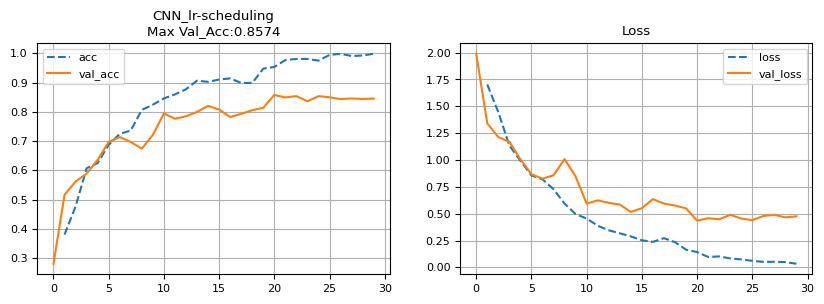